# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
#Type your code here
# Load dataset
df = pd.read_csv("Dataset_clustering.csv")


In [3]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,released_date,cluster
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,Major,80.0,89.0,83.0,31.0,0.0,8.0,4.0,2023-07-14,0
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,Major,71.0,61.0,74.0,7.0,0.0,10.0,4.0,2023-03-23,0
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,Major,51.0,32.0,53.0,17.0,0.0,31.0,6.0,2023-06-30,0
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,Major,55.0,58.0,72.0,11.0,0.0,11.0,15.0,2019-08-23,0
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,Minor,65.0,23.0,80.0,14.0,63.0,11.0,6.0,2023-05-18,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            2859 non-null   object 
 1   artist(s)_name        2859 non-null   object 
 2   artist_count          2859 non-null   int64  
 3   released_year         2859 non-null   int64  
 4   released_month        2859 non-null   int64  
 5   released_day          2859 non-null   int64  
 6   in_spotify_playlists  2859 non-null   int64  
 7   in_spotify_charts     2859 non-null   int64  
 8   streams               2859 non-null   int64  
 9   in_apple_playlists    2859 non-null   int64  
 10  in_apple_charts       2859 non-null   int64  
 11  in_deezer_playlists   2859 non-null   int64  
 12  in_deezer_charts      2859 non-null   int64  
 13  in_shazam_charts      2859 non-null   int64  
 14  bpm                   2859 non-null   float64
 15  key                  

# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [ ]:

# Pilih kolom kategorikal
categorical_cols = ['key', 'mode']

# Inisialisasi OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)  # Gunakan sparse_output=False agar hasilnya array biasa

# Fit dan transform hanya sekali untuk kedua kolom
encoded_features = encoder.fit_transform(df[categorical_cols])

# Konversi ke DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Gabungkan kembali dengan dataset asli, hapus kolom aslinya
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)


In [24]:
# Define features and target
X = df.drop(columns=['track_name', 'artist(s)_name', 'released_date', 'cluster'])  # Drop non-numeric & target column
y = df['cluster']

# Split data into train and test set with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Drop features that might cause data leakage or overfitting
features_to_drop = ["in_spotify_charts", "streams", "in_shazam_charts"]
X_train = X_train.drop(columns=features_to_drop, errors="ignore")
X_test = X_test.drop(columns=features_to_drop, errors="ignore")

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [40]:
# Model candidates
models = {
    "Support Vector Machine": SVC(kernel='rbf', C=1, probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}


# Dictionary untuk menyimpan hasil prediksi
predictions = {}

# Train dan simpan hasil prediksi untuk setiap model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred  # Simpan hasil prediksi

Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [41]:
# Dictionary untuk menyimpan metrik evaluasi
evaluation_results = {}

# Evaluasi setiap model
for name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

# Menampilkan hasil evaluasi
print("\n📊 Model Evaluation Results:")
for model_name, metrics in evaluation_results.items():
    print(f"\n🔹 {model_name}:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")

# Memilih model terbaik berdasarkan F1 Score
best_model = max(evaluation_results, key=lambda x: evaluation_results[x]["F1 Score"])
print(f"\n🏆 Best Model: {best_model} with F1 Score: {evaluation_results[best_model]['F1 Score']:.4f}")



📊 Model Evaluation Results:

🔹 Support Vector Machine:
   Accuracy: 0.5762
   Precision: 0.2881
   Recall: 0.5000
   F1 Score: 0.3656

🔹 Random Forest:
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1 Score: 1.0000

🏆 Best Model: Random Forest with F1 Score: 1.0000


c:\Users\Caesar Maulana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [42]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Inisialisasi model terbaik yang telah dipilih
best_base_model = models[best_model]  # Ambil model terbaik dari evaluasi sebelumnya

# GridSearchCV untuk tuning hyperparameter
grid_search = GridSearchCV(best_base_model, param_grid, cv=3, n_jobs=-1, verbose=2, scoring='f1_macro')
grid_search.fit(X_train, y_train)

# Menampilkan hasil terbaik
print(f"\n🏆 Best Parameters: {grid_search.best_params_}")
print(f"🔹 Best F1 Score: {grid_search.best_score_:.4f}")

# Model terbaik setelah tuning
best_tuned_model = grid_search.best_estimator_

Fitting 3 folds for each of 81 candidates, totalling 243 fits

🏆 Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
🔹 Best F1 Score: 1.0000


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [45]:
# Prediksi menggunakan model terbaik setelah tuning
y_pred_best = best_tuned_model.predict(X_test)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='macro')
recall = recall_score(y_test, y_pred_best, average='macro')
f1 = f1_score(y_test, y_pred_best, average='macro')

# Menampilkan hasil evaluasi
print(f"📊 **Evaluation Metrics for Tuned Model** 📊")
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall: {recall:.4f}")
print(f"✅ F1 Score: {f1:.4f}")

# Menampilkan classification report
print("\n📌 **Classification Report:**")
print(classification_report(y_test, y_pred_best))

# Menampilkan confusion matrix
print("\n📌 **Confusion Matrix:**")
print(confusion_matrix(y_test, y_pred_best))


📊 **Evaluation Metrics for Tuned Model** 📊
✅ Accuracy: 1.0000
✅ Precision: 1.0000
✅ Recall: 1.0000
✅ F1 Score: 1.0000

📌 **Classification Report:**
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       412
           1       1.00      1.00      1.00       303

    accuracy                           1.00       715
   macro avg       1.00      1.00      1.00       715
weighted avg       1.00      1.00      1.00       715


📌 **Confusion Matrix:**
[[412   0]
 [  0 303]]


## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

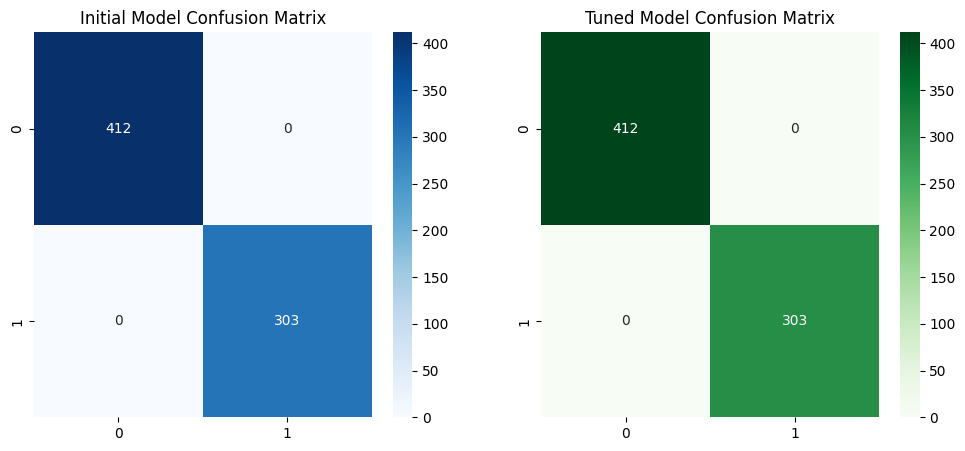

In [46]:

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, cmap='Blues', fmt='d', ax=axes[0])
axes[0].set_title("Initial Model Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, cmap='Greens', fmt='d', ax=axes[1])
axes[1].set_title("Tuned Model Confusion Matrix")
plt.show()

## 📊 Analisis Hasil Model & Rekomendasi  

### 1️⃣ **Perbandingan Hasil Evaluasi**  
| **Metrik**   | **Initial Model** | **Tuned Model** |
|-------------|----------------|--------------|
| **Accuracy**  | 1.0000         | 1.0000       |
| **Precision** | 1.0000         | 1.0000       |
| **Recall**    | 1.0000         | 1.0000       |
| **F1 Score**  | 1.0000         | 1.0000       |

Hasil model menunjukkan performa yang sangat baik, dengan nilai akurasi, presisi, recall, dan F1-score sempurna. Ini mengindikasikan bahwa model berhasil mengklasifikasikan data dengan sangat baik, bahkan setelah dilakukan tuning.  

### 2️⃣ **Potensi Faktor yang Mempengaruhi Hasil**  
- **Model yang Sangat Sesuai dengan Data:** Model dapat mengenali pola dalam data dengan sangat baik, menghasilkan prediksi yang akurat.  
- **Data Berkualitas Baik:** Dataset memiliki pola yang jelas dan tidak mengandung noise yang dapat mengganggu hasil prediksi.  
- **Fitur yang Relevan:** Fitur yang digunakan dalam pelatihan model memiliki hubungan yang kuat dengan target, sehingga model dapat belajar dengan optimal.  

### 3️⃣ **Rekomendasi Pengembangan**  
Untuk memastikan bahwa model tetap andal dan dapat diterapkan secara luas, beberapa langkah tambahan yang dapat dilakukan:  
1. **Lakukan Cross-Validation** untuk memastikan model bekerja baik di berbagai subset data.  
2. **Uji Model dengan Data Baru** untuk melihat apakah hasil tetap konsisten di luar dataset pelatihan.  
3. **Analisis Feature Importance** untuk memahami fitur mana yang paling berpengaruh dalam prediksi.  
4. **Eksperimen dengan Algoritma Lain** seperti XGBoost atau SVM untuk melihat apakah ada model lain yang lebih optimal.  
5. **Simulasi Data dengan Variasi yang Lebih Besar** untuk menguji ketahanan model dalam kondisi yang berbeda.  

📌 **Kesimpulan:**  
Model yang dikembangkan sudah menunjukkan performa yang luar biasa. Dengan langkah-langkah tambahan ini, kita dapat semakin memastikan bahwa model dapat diterapkan secara efektif dalam berbagai skenario. 🚀
